# 🖼️ Normal (Dense / Linear) Denoising Autoencoder in PyTorch

This notebook implements a **Normal (Fully Connected / Dense) Denoising Autoencoder** using PyTorch `nn.Linear` layers on the **MNIST Dataset**.

## Step 1: Environment Setup & PyTorch Imports

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using compute device: {device}")

Using compute device: cpu


## Step 2: Load Dataset from Local Datasets Folder

Loading MNIST dataset from local path: ../../Datasets


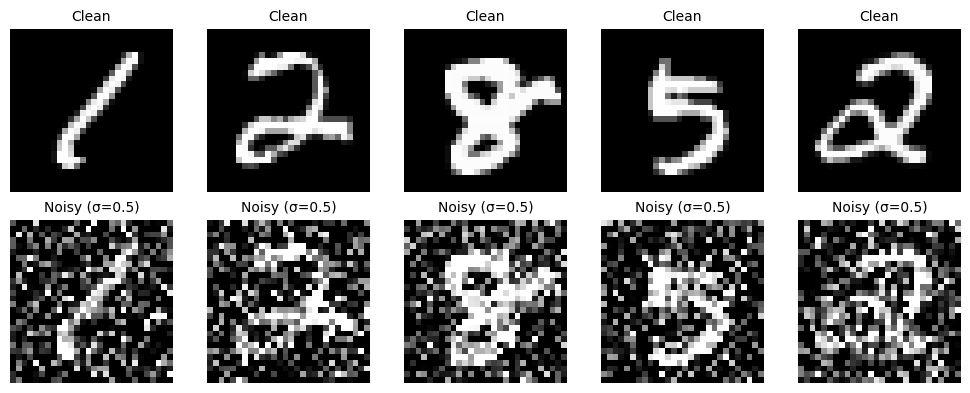

In [2]:
# Multi-path search for local Datasets folder
possible_dataset_paths = [
    r'../../Datasets',
    r'c:/Users/ADARSH S SAHOO/Desktop/Engineering folder/AI-ML_2027/Datasets',
    r'./data'
]

data_dir = None
for p in possible_dataset_paths:
    if os.path.exists(os.path.join(p, 'MNIST')):
        data_dir = p
        break

if data_dir is None:
    data_dir = './data'

print(f"Loading MNIST dataset from local path: {data_dir}")
transform = transforms.Compose([transforms.ToTensor()])

# Load from local Datasets without redownloading (download=False)
train_dataset = torchvision.datasets.MNIST(root=data_dir, train=True, download=False, transform=transform)
test_dataset = torchvision.datasets.MNIST(root=data_dir, train=False, download=False, transform=transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Additive Gaussian noise function
def add_gaussian_noise(images, noise_factor=0.5):
    noisy = images + noise_factor * torch.randn_like(images)
    return torch.clamp(noisy, 0.0, 1.0)

# Visualize Clean vs. Noisy Samples
clean_samples, _ = next(iter(train_loader))
noisy_samples = add_gaussian_noise(clean_samples, noise_factor=0.5)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    axes[0, i].imshow(clean_samples[i].squeeze(), cmap='gray')
    axes[0, i].set_title("Clean", fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(noisy_samples[i].squeeze(), cmap='gray')
    axes[1, i].set_title("Noisy (σ=0.5)", fontsize=10)
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()


## Step 3: Normal Linear Autoencoder Class (`NormalAutoencoder`)

In [3]:
class NormalAutoencoder(nn.Module):
    def __init__(self, input_dim=784, bottleneck_dim=64):
        super(NormalAutoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, bottleneck_dim),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)
        latent = self.encoder(x_flat)
        reconstructed_flat = self.decoder(latent)
        return reconstructed_flat.view(batch_size, 1, 28, 28)

model = NormalAutoencoder().to(device)
print(model)

NormalAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


## Step 4: Training Routine

In [4]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 10
NOISE_FACTOR = 0.5

train_losses = []
print("Training Normal (Linear) Autoencoder...")
for epoch in range(1, EPOCHS + 1):
    running_loss = 0.0
    for clean_imgs, _ in train_loader:
        clean_imgs = clean_imgs.to(device)
        noisy_imgs = add_gaussian_noise(clean_imgs, noise_factor=NOISE_FACTOR).to(device)
        
        optimizer.zero_grad()
        outputs = model(noisy_imgs)
        loss = criterion(outputs, clean_imgs)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * clean_imgs.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] ---> MSE Loss: {epoch_loss:.5f}")

torch.save(model.state_dict(), 'normal_autoencoder.pth')
print("✅ Saved weights to 'normal_autoencoder.pth'!")

Training Normal (Linear) Autoencoder...
Epoch [01/10] ---> MSE Loss: 0.04287
Epoch [02/10] ---> MSE Loss: 0.02474
Epoch [03/10] ---> MSE Loss: 0.02106
Epoch [04/10] ---> MSE Loss: 0.01930
Epoch [05/10] ---> MSE Loss: 0.01809
Epoch [06/10] ---> MSE Loss: 0.01733
Epoch [07/10] ---> MSE Loss: 0.01679
Epoch [08/10] ---> MSE Loss: 0.01638
Epoch [09/10] ---> MSE Loss: 0.01608
Epoch [10/10] ---> MSE Loss: 0.01577
✅ Saved weights to 'normal_autoencoder.pth'!


## Step 5: Visualizing Results

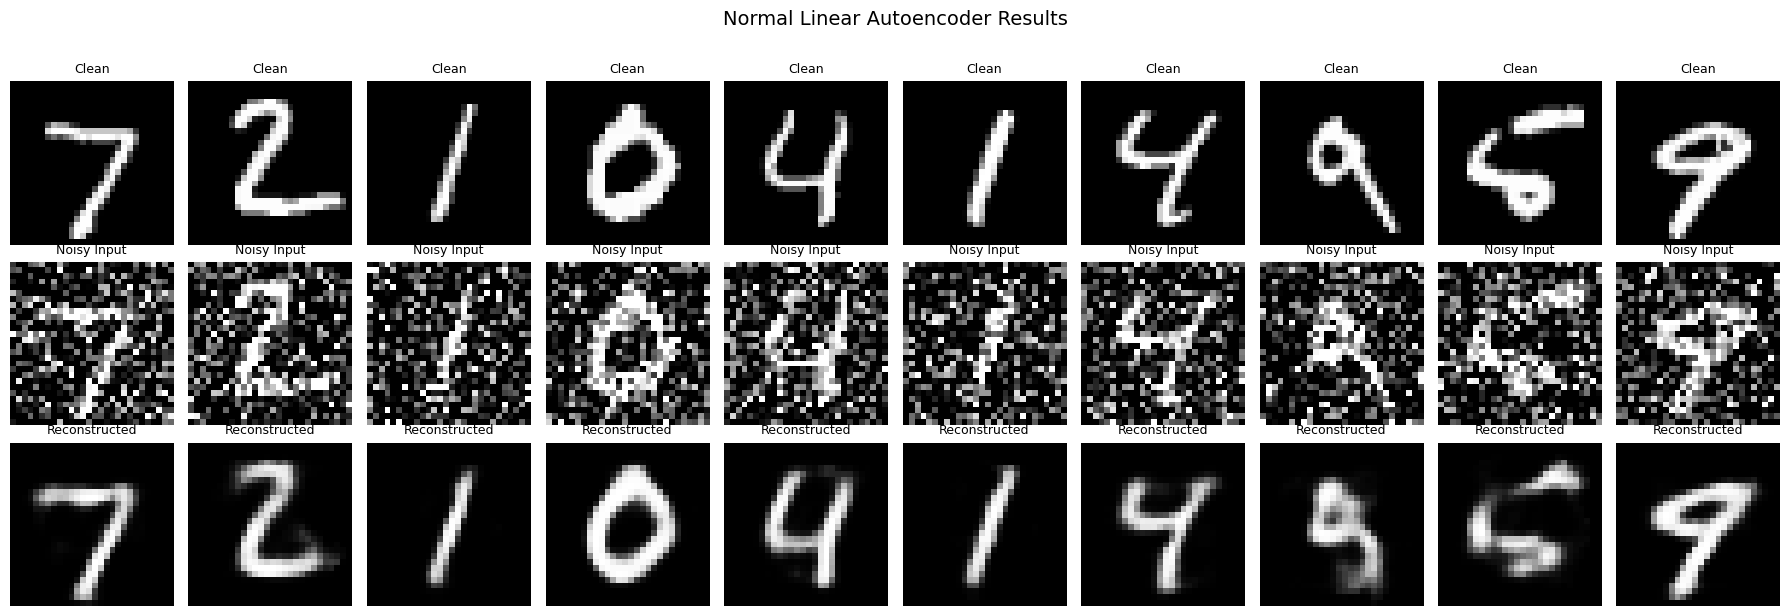

In [5]:
model.eval()
with torch.no_grad():
    test_clean, _ = next(iter(test_loader))
    test_clean = test_clean.to(device)
    test_noisy = add_gaussian_noise(test_clean, noise_factor=NOISE_FACTOR).to(device)
    denoised_outputs = model(test_noisy)

fig, axes = plt.subplots(3, 10, figsize=(18, 6))
for i in range(10):
    axes[0, i].imshow(test_clean[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title("Clean", fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(test_noisy[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title("Noisy Input", fontsize=9)
    axes[1, i].axis('off')
    axes[2, i].imshow(denoised_outputs[i].cpu().squeeze(), cmap='gray')
    axes[2, i].set_title("Reconstructed", fontsize=9)
    axes[2, i].axis('off')
plt.suptitle("Normal Linear Autoencoder Results", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()